# Remote-estimation fine-beta zoom: seed 1111 versus seed 1000

This notebook compares the completed seed-1111 zoom with the new seed-1000 run at $\gamma=0.9$. Circles are revealing solutions (zero accessible violations) and crosses are non-revealing solutions. The CMAB boundary is

$$\beta_{\min}(\epsilon)=\frac{\gamma\epsilon(1-\epsilon)}{1-\gamma^2}.$$

Result markers always use full opacity. Solver precision is shown only in its dedicated heatmap.

In [17]:
from pathlib import Path
import json

from IPython.display import Markdown, display
from matplotlib.colors import Normalize, SymLogNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPOSITORY_ROOT = next(
    candidate for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / 'mdp.py').is_file()
)
DATA_DIR = (
    REPOSITORY_ROOT / 'experiments' / 'jpo_exps' / 'cmab_exps'
    / 'remote_estimation_revealing_grid'
)
PLOT_DIR = DATA_DIR / 'plots' / 'seed_1000'
PLOT_DIR.mkdir(parents=True, exist_ok=True)
TARGET_GAMMA = 0.9

SOURCES = [
    {
        'key': 'seed_1111',
        'directory': 'beta_01_02_03_04',
        'label': 'MDP seed 1111',
        'color': '#2f6fbb',
    },
    {
        'key': 'seed_1000',
        'directory': 'beta_01_02_03_04_seed_1000',
        'label': 'MDP seed 1000',
        'color': '#b2473e',
    },
]

REQUIRED_COLUMNS = {
    'status', 'point_id', 'gamma', 'beta', 'epsilon', 'violation_count',
    'sarsop_gap', 'solver_stop_reason', 'discounted_transmission_occupancy',
}

def load_grid(source):
    path = DATA_DIR / source['directory'] / 'results.json'
    payload = json.loads(path.read_text(encoding='utf-8'))
    experiment = payload['experiment']
    points = pd.DataFrame(payload.get('points', []))
    if points.empty:
        points = pd.DataFrame(columns=sorted(REQUIRED_COLUMNS))
    else:
        missing = REQUIRED_COLUMNS.difference(points.columns)
        assert not missing, f'{source["directory"]}: missing {sorted(missing)}'
        points = points[np.isclose(points['gamma'], TARGET_GAMMA)].copy()
        points = points[points['status'] == 'ok'].copy()
        assert not points.duplicated(['beta', 'epsilon']).any()
    points['grid'] = source['key']
    points['revealing'] = points['violation_count'].eq(0)
    return experiment, points.sort_values(['beta', 'epsilon']).reset_index(drop=True)

experiments = {}
grids = {}
for source in SOURCES:
    experiments[source['key']], grids[source['key']] = load_grid(source)

assert experiments['seed_1111']['mdp_seed'] == 1111
assert experiments['seed_1000']['mdp_seed'] == 1000
for key in ['n_states', 'n_actions', 'density', 'gammas', 'betas', 'epsilons']:
    assert experiments['seed_1111'][key] == experiments['seed_1000'][key]

frame = pd.concat(grids.values(), ignore_index=True)
summary = pd.DataFrame([
    {
        'seed': experiments[source['key']]['mdp_seed'],
        'completed': len(grids[source['key']]),
        'expected': experiments[source['key']]['expected_points'],
        'revealing': int(grids[source['key']]['revealing'].sum()),
        'non_revealing': int((~grids[source['key']]['revealing']).sum()),
        'max_sarsop_gap': (
            np.nan if grids[source['key']].empty
            else grids[source['key']]['sarsop_gap'].max()
        ),
    }
    for source in SOURCES
])
display(summary)


,seed,completed,expected,revealing,non_revealing,max_sarsop_gap
0,1111,40,40,40,0,0.012246
1,1000,40,40,40,0,0.011080


## Revealing boundary comparison

The seed-1000 panel can be rerun while results are partial; completed points appear as they are merged into `results.json`.

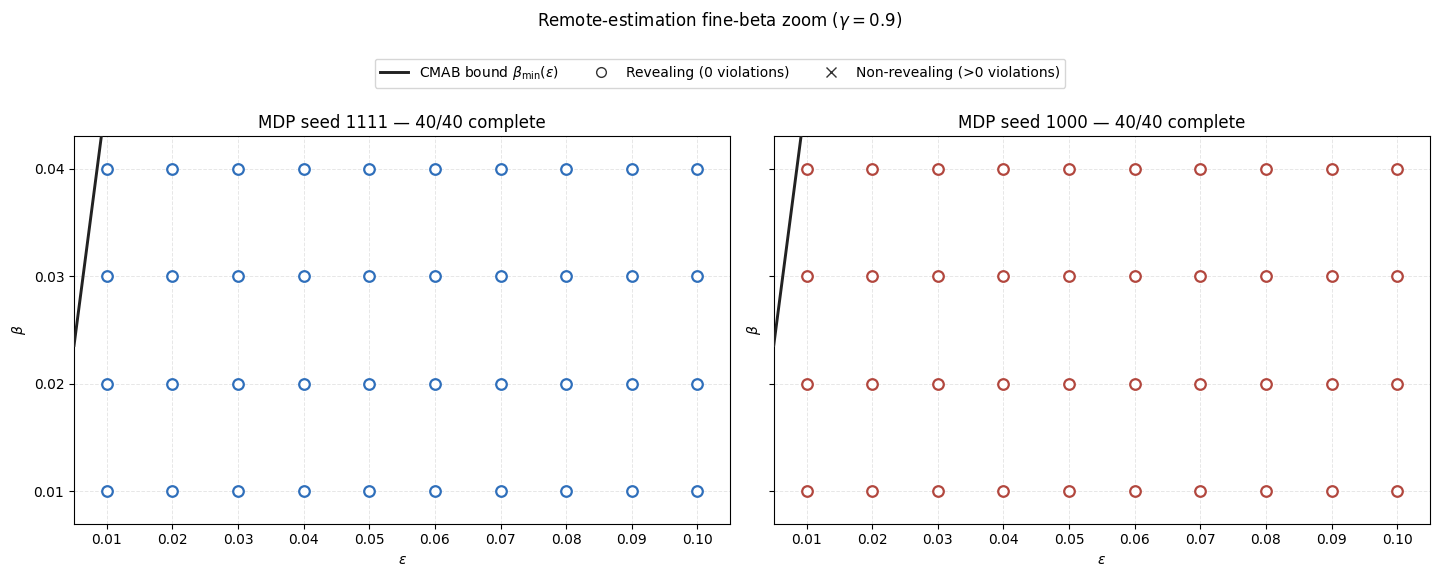

Figure saved to `experiments/jpo_exps/cmab_exps/remote_estimation_revealing_grid/plots/seed_1000/gamma_0p9_zoom_seed_comparison.png`.

In [18]:
def beta_min(epsilon, gamma=TARGET_GAMMA):
    epsilon = np.asarray(epsilon, dtype=float)
    return gamma * epsilon * (1.0 - epsilon) / (1.0 - gamma**2)

def add_points(ax, points, color):
    revealing = points[points['revealing']]
    non_revealing = points[~points['revealing']]
    ax.scatter(
        revealing['epsilon'], revealing['beta'], s=58, marker='o',
        facecolors='white', edgecolors=color, linewidths=1.6,
        alpha=1.0, zorder=4,
    )
    ax.scatter(
        non_revealing['epsilon'], non_revealing['beta'], s=55, marker='x',
        color=color, linewidths=1.8, alpha=1.0, zorder=5,
    )

epsilon_dense = np.linspace(0.005, 0.105, 800)
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.2), sharex=True, sharey=True)
for ax, source in zip(axes, SOURCES):
    points = grids[source['key']]
    ax.plot(epsilon_dense, beta_min(epsilon_dense),
            color='#222222', linewidth=2.1, zorder=3)
    add_points(ax, points, source['color'])
    ax.set_xlim(0.005, 0.105)
    ax.set_ylim(0.007, 0.043)
    ax.set_xticks(np.arange(0.01, 0.101, 0.01))
    ax.set_yticks([0.01, 0.02, 0.03, 0.04])
    ax.set_xlabel(r'$\epsilon$')
    ax.set_ylabel(r'$\beta$')
    ax.set_title(
        f'{source["label"]} — {len(points)}/'
        f'{experiments[source["key"]]["expected_points"]} complete'
    )
    ax.grid(alpha=0.30, linestyle='--', linewidth=0.7)

legend_handles = [
    Line2D([0], [0], color='#222222', lw=2.1,
           label=r'CMAB bound $\beta_{\min}(\epsilon)$'),
    Line2D([0], [0], marker='o', linestyle='None', markersize=7,
           markerfacecolor='white', markeredgecolor='#333333',
           label='Revealing (0 violations)'),
    Line2D([0], [0], marker='x', linestyle='None', markersize=7,
           color='#333333', label='Non-revealing (>0 violations)'),
]
fig.legend(handles=legend_handles, loc='upper center', ncol=3,
           bbox_to_anchor=(0.5, 1.02), frameon=True)
fig.suptitle(r'Remote-estimation fine-beta zoom ($\gamma=0.9$)', y=1.10)
fig.tight_layout()
OUTPUT_BOUNDARY = PLOT_DIR / 'gamma_0p9_zoom_seed_comparison.png'
fig.savefig(OUTPUT_BOUNDARY, dpi=220, bbox_inches='tight')
plt.show()
display(Markdown(f'Figure saved to `{OUTPUT_BOUNDARY.relative_to(REPOSITORY_ROOT)}`.'))


## Solver precision

The final SARSOP certificate $U-L$ is shown independently of the revealing markers. Red borders indicate `max_time` stops.

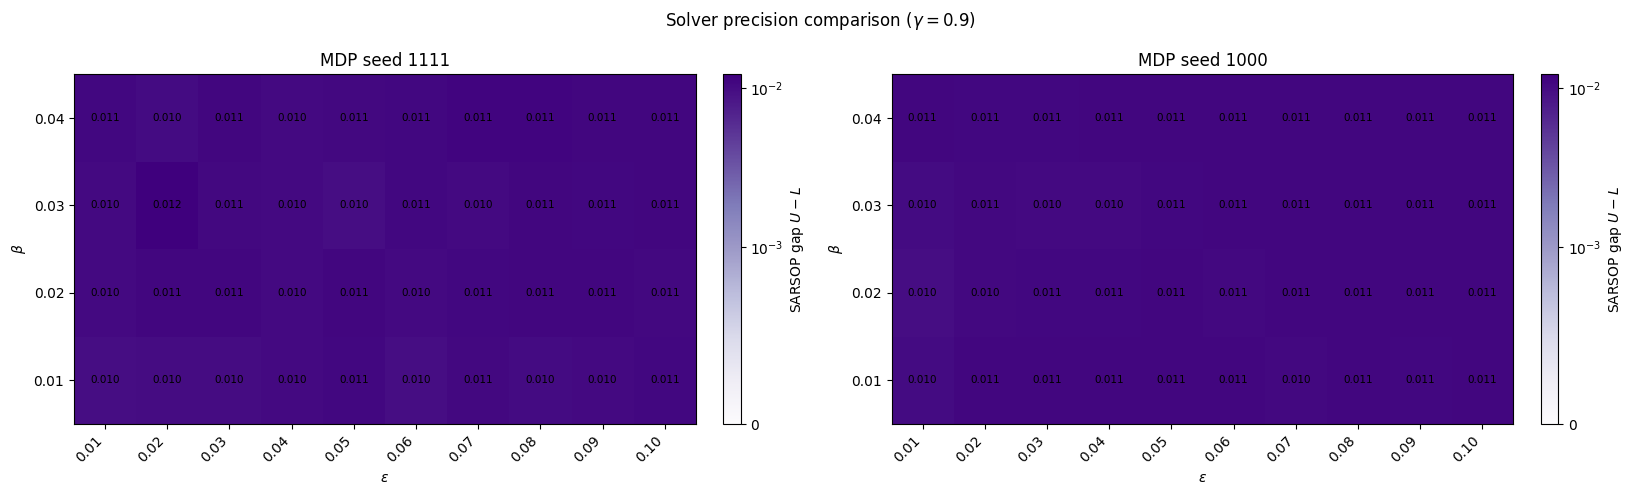

Figure saved to `experiments/jpo_exps/cmab_exps/remote_estimation_revealing_grid/plots/seed_1000/gamma_0p9_zoom_solver_precision.png`.

In [19]:
def grid_matrix(source, column):
    experiment = experiments[source['key']]
    points = grids[source['key']]
    betas = np.asarray(experiment['betas'], dtype=float)
    epsilons = np.asarray(experiment['epsilons'], dtype=float)
    if points.empty:
        matrix = pd.DataFrame(np.nan, index=betas, columns=epsilons)
    else:
        matrix = (
            points.pivot(index='beta', columns='epsilon', values=column)
            .reindex(index=betas, columns=epsilons)
        )
    return matrix, betas, epsilons

def draw_heatmap(ax, source, column, cmap_name, norm, formatter):
    matrix, betas, epsilons = grid_matrix(source, column)
    values = matrix.to_numpy(dtype=float)
    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_bad('#d9d9d9')
    image = ax.imshow(np.ma.masked_invalid(values), origin='lower',
                      aspect='auto', cmap=cmap, norm=norm)
    for row, column_index in np.argwhere(np.isfinite(values)):
        ax.text(column_index, row, formatter(values[row, column_index]),
                ha='center', va='center', fontsize=7.5)
    ax.set_xticks(range(len(epsilons)), [f'{value:.2f}' for value in epsilons],
                  rotation=45, ha='right')
    ax.set_yticks(range(len(betas)), [f'{value:.2f}' for value in betas])
    ax.set_xlabel(r'$\epsilon$')
    ax.set_ylabel(r'$\beta$')
    ax.set_title(source['label'])
    return image

finite_gaps = frame['sarsop_gap'].to_numpy(dtype=float)
finite_gaps = finite_gaps[np.isfinite(finite_gaps)]
gap_norm = SymLogNorm(
    linthresh=1e-3, vmin=0.0,
    vmax=max(1e-3, float(finite_gaps.max())),
)
fig, axes = plt.subplots(1, 2, figsize=(16.5, 5.0))
for ax, source in zip(axes, SOURCES):
    image = draw_heatmap(
        ax, source, 'sarsop_gap', 'Purples', gap_norm,
        lambda value: f'{value:.3f}',
    )
    stop_matrix, _, _ = grid_matrix(source, 'solver_stop_reason')
    for row, column_index in np.argwhere(stop_matrix.to_numpy(dtype=object) == 'max_time'):
        ax.add_patch(Rectangle(
            (column_index - 0.5, row - 0.5), 1, 1,
            fill=False, edgecolor='#c44e52', linewidth=2.2,
        ))
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04,
                 label='SARSOP gap $U-L$')

fig.suptitle(r'Solver precision comparison ($\gamma=0.9$)')
fig.tight_layout()
OUTPUT_PRECISION = PLOT_DIR / 'gamma_0p9_zoom_solver_precision.png'
fig.savefig(OUTPUT_PRECISION, dpi=220, bbox_inches='tight')
plt.show()
display(Markdown(f'Figure saved to `{OUTPUT_PRECISION.relative_to(REPOSITORY_ROOT)}`.'))


## Discounted transmission occupancy

Both seeds use the same absolute scale $[0,\gamma/(1-\gamma)]=[0,9]$.

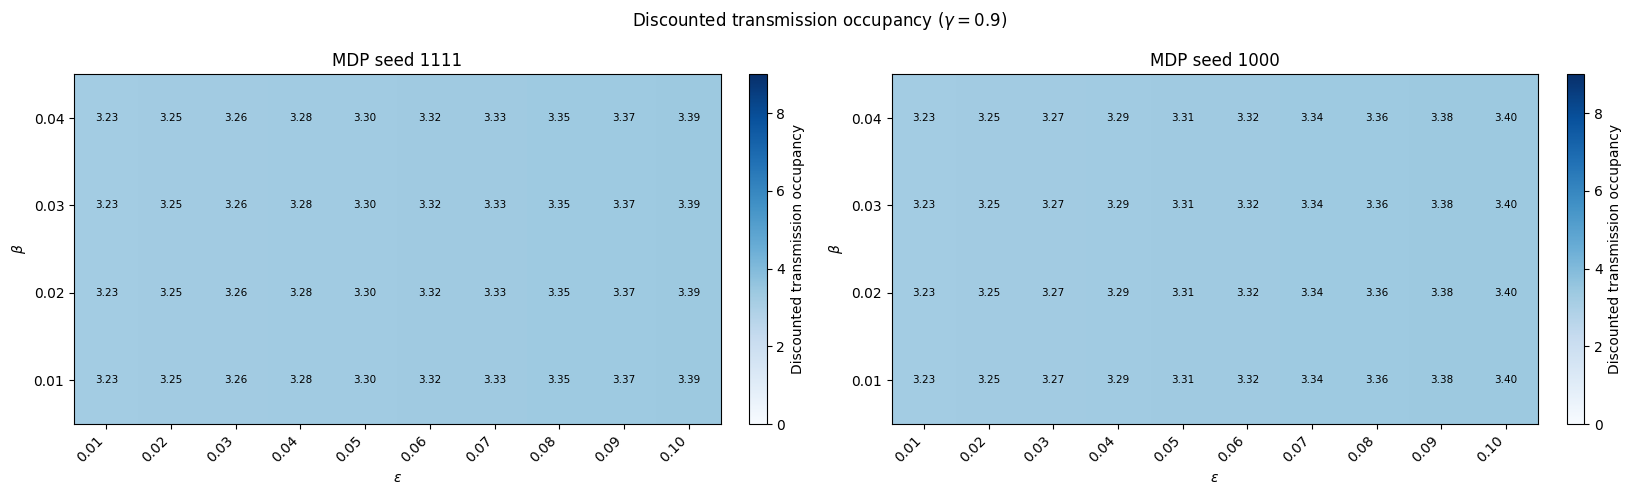

Figure saved to `experiments/jpo_exps/cmab_exps/remote_estimation_revealing_grid/plots/seed_1000/gamma_0p9_zoom_transmission.png`.

In [20]:
transmission_norm = Normalize(vmin=0.0, vmax=TARGET_GAMMA / (1.0 - TARGET_GAMMA))
fig, axes = plt.subplots(1, 2, figsize=(16.5, 5.0))
for ax, source in zip(axes, SOURCES):
    image = draw_heatmap(
        ax, source, 'discounted_transmission_occupancy', 'Blues',
        transmission_norm, lambda value: f'{value:.2f}',
    )
    fig.colorbar(
        image, ax=ax, fraction=0.046, pad=0.04,
        label='Discounted transmission occupancy',
    )

fig.suptitle(r'Discounted transmission occupancy ($\gamma=0.9$)')
fig.tight_layout()
OUTPUT_TRANSMISSION = PLOT_DIR / 'gamma_0p9_zoom_transmission.png'
fig.savefig(OUTPUT_TRANSMISSION, dpi=220, bbox_inches='tight')
plt.show()
display(Markdown(f'Figure saved to `{OUTPUT_TRANSMISSION.relative_to(REPOSITORY_ROOT)}`.'))
